In [170]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from sklearn.model_selection import KFold, train_test_split
from sklearn.datasets import load_iris

In [171]:
class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, X, y):
        self.tree = self._build_tree(X, y)

    def _build_tree(self, X, y, depth=0):
        num_samples, num_features = X.shape
        unique_classes = np.unique(y)
        
        # If all samples have the same label or max depth reached
        if len(unique_classes) == 1 or (self.max_depth and depth == self.max_depth):
            return unique_classes[0]

        # Find the best split
        best_feature, best_threshold = self._best_split(X, y)
        if best_feature is None:
            return np.bincount(y).argmax()

        left_indices = X[:, best_feature] <= best_threshold
        right_indices = X[:, best_feature] > best_threshold
        
        left_subtree = self._build_tree(X[left_indices], y[left_indices], depth + 1)
        right_subtree = self._build_tree(X[right_indices], y[right_indices], depth + 1)
        
        return (best_feature, best_threshold, left_subtree, right_subtree)

    def _best_split(self, X, y):
        num_samples, num_features = X.shape
        best_feature, best_threshold = None, None
        best_gini = float('inf')

        for feature in range(num_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_indices = X[:, feature] <= threshold
                right_indices = X[:, feature] > threshold
                
                if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
                    continue

                gini_left = 1.0 - sum((np.sum(y[left_indices] == c) / len(y[left_indices])) ** 2 for c in np.unique(y))
                gini_right = 1.0 - sum((np.sum(y[right_indices] == c) / len(y[right_indices])) ** 2 for c in np.unique(y))
                
                gini = (len(y[left_indices]) / len(y)) * gini_left + (len(y[right_indices]) / len(y)) * gini_right
                
                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def predict(self, X):
        return np.array([self._predict_sample(x, self.tree) for x in X])

    def _predict_sample(self, x, tree):
        if not isinstance(tree, tuple):
            return tree
        feature, threshold, left_subtree, right_subtree = tree
        if x[feature] <= threshold:
            return self._predict_sample(x, left_subtree)
        else:
            return self._predict_sample(x, right_subtree)

In [172]:
class BaggingClassifier:
    def __init__(self, base_model, n_estimators=10):
        self.base_model = base_model
        self.n_estimators = n_estimators
        self.models = []

    def fit(self, X, y):
        num_samples = X.shape[0]
        for _ in range(self.n_estimators):
            indices = np.random.choice(num_samples, num_samples, replace=True)
            X_bootstrap, y_bootstrap = X[indices], y[indices]
            model = self.base_model
            model.fit(X_bootstrap, y_bootstrap)
            self.models.append(model)

    def predict(self, X):
        predictions = np.array([model.predict(X) for model in self.models])
        majority_votes = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=predictions)
        return majority_votes


In [173]:
class RandomForestClassifier:
    def __init__(self, n_estimators=10, max_features=None):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        num_samples, num_features = X.shape
        if self.max_features is None:
            self.max_features = num_features
        else:
            self.max_features = min(self.max_features, num_features)  # Adjust max_features

        for _ in range(self.n_estimators):
            features = np.random.choice(num_features, self.max_features, replace=False)
            X_bootstrap, y_bootstrap = self._bootstrap(X[:, features], y)
            tree = DecisionTree(max_depth=None)
            tree.fit(X_bootstrap, y_bootstrap)
            self.trees.append((tree, features))

    def _bootstrap(self, X, y):
        num_samples = X.shape[0]
        indices = np.random.choice(num_samples, num_samples, replace=True)
        return X[indices], y[indices]

    def predict(self, X):
        predictions = np.array([tree.predict(X[:, features]) for tree, features in self.trees])
        majority_votes = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=predictions)
        return majority_votes


In [174]:
class GradientBoostingClassifier:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.models = []

    def fit(self, X, y):
        residuals = y.astype(float)  
        for _ in range(self.n_estimators):
            model = DecisionTree(max_depth=self.max_depth)
            model.fit(X, residuals)
            predictions = model.predict(X)
            residuals -= self.learning_rate * predictions
            self.models.append(model)

    def predict(self, X):
        predictions = np.zeros(X.shape[0], dtype=float)  
        for model in self.models:
            predictions += self.learning_rate * model.predict(X)
        return np.round(predictions).astype(int)

In [175]:
def k_fold_cross_validation(model, X, y, k=4):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    accuracy = []
    validation_accuracy = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        accuracy.append(np.mean(y_pred_train == y_train))
        validation_accuracy.append(np.mean(y_pred_val == y_val))

    return np.mean(accuracy), np.mean(validation_accuracy)

In [176]:
def detailed_grid_search(model_class, param_grid, X, y, k=4, **kwargs):
    keys, values = zip(*param_grid.items())
    results = []
    for v in product(*values):
        params = dict(zip(keys, v))
        model_params = {**kwargs, **params}
        model = model_class(**model_params)
        accuracy, val_accuracy = k_fold_cross_validation(model, X, y, k)
        results.append((params, accuracy, val_accuracy))
        print(f"Parameters: {params}, Training Accuracy: {accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}")
    return results


In [177]:
def grid_search(model_class, param_grid, X, y, k=4, **kwargs):
    best_params = None
    best_accuracy = 0

    keys, values = zip(*param_grid.items())
    for v in product(*values):
        params = dict(zip(keys, v))
        model_params = {**kwargs, **params}
        model = model_class(**model_params)
        accuracy, _ = k_fold_cross_validation(model, X, y, k)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_params = params

    return best_params, best_accuracy


In [178]:
param_grids = {
    "Decision Tree": {"max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10]},
    "Bagging": {"n_estimators": [10, 15, 20, 25, 30]},
    "Random Forest": {"n_estimators": [10, 20, 30], "max_features": [2, 3, 4]},
    "Gradient Boosting": {"n_estimators": [10, 20, 30], "learning_rate": [0.01, 0.1, 0.2], "max_depth": [3, 5, 7]}
}

In [179]:
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [180]:
results = {}
best_params = {}


print("Decision Tree Grid Search:")
results['Decision Tree'] = detailed_grid_search(DecisionTree, param_grids["Decision Tree"], X_train, y_train)

best_params_decision_tree, _ = grid_search(DecisionTree, param_grids["Decision Tree"], X_train, y_train)

print("\n\n Best Parameters for Decision Tree:", best_params_decision_tree)


best_decision_tree_model = DecisionTree(**best_params_decision_tree)
best_decision_tree_model.fit(X_train, y_train)


y_test_pred = best_decision_tree_model.predict(X_test)


test_accuracy_decision_tree = np.mean(y_test_pred == y_test)
print("\n\n Test Accuracy of Decision Tree with Best Parameters: {:.4f}".format(test_accuracy_decision_tree))

Decision Tree Grid Search:
Parameters: {'max_depth': 2}, Training Accuracy: 0.6476, Validation Accuracy: 0.6471
Parameters: {'max_depth': 3}, Training Accuracy: 0.8892, Validation Accuracy: 0.7984
Parameters: {'max_depth': 4}, Training Accuracy: 0.9715, Validation Accuracy: 0.8946
Parameters: {'max_depth': 5}, Training Accuracy: 0.9937, Validation Accuracy: 0.8946
Parameters: {'max_depth': 6}, Training Accuracy: 1.0000, Validation Accuracy: 0.8946
Parameters: {'max_depth': 7}, Training Accuracy: 1.0000, Validation Accuracy: 0.8946
Parameters: {'max_depth': 8}, Training Accuracy: 1.0000, Validation Accuracy: 0.8946
Parameters: {'max_depth': 9}, Training Accuracy: 1.0000, Validation Accuracy: 0.8946
Parameters: {'max_depth': 10}, Training Accuracy: 1.0000, Validation Accuracy: 0.8946


 Best Parameters for Decision Tree: {'max_depth': 6}


 Test Accuracy of Decision Tree with Best Parameters: 0.9556


In [181]:
print("Bagging Grid Search:")
results['Bagging'] = detailed_grid_search(BaggingClassifier, param_grids["Bagging"], X_train, y_train, base_model=DecisionTree())


best_params_bagging, _ = grid_search(BaggingClassifier, param_grids["Bagging"], X_train, y_train, k=4, base_model=DecisionTree())


print("\n\n Best Parameters for Bagging Classifier:", best_params_bagging)


best_bagging_model = BaggingClassifier(base_model=DecisionTree(), **best_params_bagging)
best_bagging_model.fit(X_train, y_train)


y_test_pred = best_bagging_model.predict(X_test)


test_accuracy_bagging = np.mean(y_test_pred == y_test)
print("\n\n Test Accuracy of Bagging Classifier with Best Parameters: {:.4f}".format(test_accuracy_bagging))

Bagging Grid Search:
Parameters: {'n_estimators': 10}, Training Accuracy: 0.9746, Validation Accuracy: 0.9238
Parameters: {'n_estimators': 15}, Training Accuracy: 0.9683, Validation Accuracy: 0.8757
Parameters: {'n_estimators': 20}, Training Accuracy: 0.9652, Validation Accuracy: 0.8946
Parameters: {'n_estimators': 25}, Training Accuracy: 0.9746, Validation Accuracy: 0.9142
Parameters: {'n_estimators': 30}, Training Accuracy: 0.9589, Validation Accuracy: 0.8668


 Best Parameters for Bagging Classifier: {'n_estimators': 15}


 Test Accuracy of Bagging Classifier with Best Parameters: 0.9556


In [182]:
print("Random Forest Grid Search:")
results['Random Forest'] = detailed_grid_search(RandomForestClassifier, param_grids["Random Forest"], X_train, y_train)


best_params_rf, _ = grid_search(RandomForestClassifier, param_grids["Random Forest"], X_train, y_train, k=4,)


print("\n\n Best Parameters for Random Forest Classifier:", best_params_rf)


best_rf_model = RandomForestClassifier(**best_params_rf)
best_rf_model.fit(X_train, y_train)


y_test_pred = best_rf_model.predict(X_test)


test_accuracy_rf = np.mean(y_test_pred == y_test)
print("\n\n Test Accuracy of Random Forest Classifier with Best Parameters: {:.4f}".format(test_accuracy_rf))




Random Forest Grid Search:
Parameters: {'n_estimators': 10, 'max_features': 2}, Training Accuracy: 0.9905, Validation Accuracy: 0.9719
Parameters: {'n_estimators': 10, 'max_features': 3}, Training Accuracy: 0.9905, Validation Accuracy: 0.9623
Parameters: {'n_estimators': 10, 'max_features': 4}, Training Accuracy: 0.9810, Validation Accuracy: 0.9719
Parameters: {'n_estimators': 20, 'max_features': 2}, Training Accuracy: 0.9873, Validation Accuracy: 0.9719
Parameters: {'n_estimators': 20, 'max_features': 3}, Training Accuracy: 0.9810, Validation Accuracy: 0.9719
Parameters: {'n_estimators': 20, 'max_features': 4}, Training Accuracy: 0.9715, Validation Accuracy: 0.9530
Parameters: {'n_estimators': 30, 'max_features': 2}, Training Accuracy: 0.9842, Validation Accuracy: 0.9530
Parameters: {'n_estimators': 30, 'max_features': 3}, Training Accuracy: 0.9873, Validation Accuracy: 0.9719
Parameters: {'n_estimators': 30, 'max_features': 4}, Training Accuracy: 0.9842, Validation Accuracy: 0.9623



In [167]:
print("Gradient Boosting Grid Search:")
results['Gradient Boosting'] = detailed_grid_search(GradientBoostingClassifier, param_grids["Gradient Boosting"], X_train, y_train)


best_params_gb, _ = grid_search(GradientBoostingClassifier, param_grids["Gradient Boosting"], X_train, y_train, k=4)


print("\n\n Best Parameters for Gradient Boosting Classifier:", best_params_gb)


best_gb_model = GradientBoostingClassifier(**best_params_gb)
best_gb_model.fit(X_train, y_train)


y_test_pred = best_gb_model.predict(X_test)


test_accuracy_gb = np.mean(y_test_pred == y_test)
print("\n\n Test Accuracy of Gradient Boosting Classifier with Best Parameters: {:.4f}".format(test_accuracy_gb))


Gradient Boosting Grid Search:
Parameters: {'n_estimators': 10, 'learning_rate': 0.01, 'max_depth': 3}, Training Accuracy: 0.2952, Validation Accuracy: 0.2952
Parameters: {'n_estimators': 10, 'learning_rate': 0.01, 'max_depth': 5}, Training Accuracy: 0.2952, Validation Accuracy: 0.2952
Parameters: {'n_estimators': 10, 'learning_rate': 0.01, 'max_depth': 7}, Training Accuracy: 0.2952, Validation Accuracy: 0.2952
Parameters: {'n_estimators': 10, 'learning_rate': 0.1, 'max_depth': 3}, Training Accuracy: 0.4735, Validation Accuracy: 0.5125
Parameters: {'n_estimators': 10, 'learning_rate': 0.1, 'max_depth': 5}, Training Accuracy: 0.4672, Validation Accuracy: 0.4836
Parameters: {'n_estimators': 10, 'learning_rate': 0.1, 'max_depth': 7}, Training Accuracy: 0.4640, Validation Accuracy: 0.4836
Parameters: {'n_estimators': 10, 'learning_rate': 0.2, 'max_depth': 3}, Training Accuracy: 0.4778, Validation Accuracy: 0.4434
Parameters: {'n_estimators': 10, 'learning_rate': 0.2, 'max_depth': 5}, Train

In [169]:
best_params = {}

best_params['Decision Tree'], _ = grid_search(DecisionTree, param_grids["Decision Tree"], X_train, y_train)
print(f"Best Parameters for Decision Tree: {best_params['Decision Tree']}")

base_model = DecisionTree(max_depth=6)  
best_params['Bagging'], _ = grid_search(BaggingClassifier, param_grids["Bagging"], X_train, y_train, k=4, base_model=base_model)
print(f"Best Parameters for Bagging Classifier: {best_params['Bagging']}")

best_params['Random Forest'], _ = grid_search(RandomForestClassifier, param_grids["Random Forest"], X_train, y_train, k=4)
print(f"Best Parameters for Random Forest Classifier: {best_params['Random Forest']}")

best_params['Gradient Boosting'], _ = grid_search(GradientBoostingClassifier, param_grids["Gradient Boosting"], X_train, y_train, k=4)
print(f"Best Parameters for Gradient Boosting Classifier: {best_params['Gradient Boosting']}")


Best Parameters for Decision Tree: {'max_depth': 6}
Best Parameters for Bagging Classifier: {'n_estimators': 15}
Best Parameters for Random Forest Classifier: {'n_estimators': 10, 'max_features': 3}
Best Parameters for Gradient Boosting Classifier: {'n_estimators': 30, 'learning_rate': 0.01, 'max_depth': 7}


In [16]:
def plot_decision_tree(results):
    depths, train_accuracies, val_accuracies = zip(*[(result[0]['max_depth'], result[1], result[2]) for result in results])
    plt.figure(figsize=(10, 5))
    plt.plot(depths, train_accuracies, marker='o', label='Training Accuracy')
    plt.plot(depths, val_accuracies, marker='o', label='Validation Accuracy')
    plt.title('Decision Tree Classifier: Accuracy vs. Max Depth')
    plt.xlabel('Max Depth')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_bagging(results):
    n_estimators, train_accuracies, val_accuracies = zip(*[(result[0]['n_estimators'], result[1], result[2]) for result in results])
    plt.figure(figsize=(10, 5))
    plt.plot(n_estimators, train_accuracies, marker='o', label='Training Accuracy')
    plt.plot(n_estimators, val_accuracies, marker='o', label='Validation Accuracy')
    plt.title('Bagging Classifier: Accuracy vs. Number of Estimators')
    plt.xlabel('Number of Estimators')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_random_forest(results):
    n_estimators = sorted(set(result[0]['n_estimators'] for result in results))
    max_features = sorted(set(result[0]['max_features'] for result in results))
    
    train_accuracies = np.zeros((len(n_estimators), len(max_features)))
    val_accuracies = np.zeros((len(n_estimators), len(max_features)))
    
    for result in results:
        n_idx = n_estimators.index(result[0]['n_estimators'])
        m_idx = max_features.index(result[0]['max_features'])
        train_accuracies[n_idx, m_idx] = result[1]
        val_accuracies[n_idx, m_idx] = result[2]
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(train_accuracies, annot=True, xticklabels=max_features, yticklabels=n_estimators, cmap='coolwarm')
    plt.title('Random Forest Classifier: Training Accuracy')
    plt.xlabel('Max Features')
    plt.ylabel('Number of Estimators')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.heatmap(val_accuracies, annot=True, xticklabels=max_features, yticklabels=n_estimators, cmap='coolwarm')
    plt.title('Random Forest Classifier: Validation Accuracy')
    plt.xlabel('Max Features')
    plt.ylabel('Number of Estimators')
    plt.show()


def plot_gradient_boosting(results):
    n_estimators = sorted(set(result[0]['n_estimators'] for result in results))
    learning_rates = sorted(set(result[0]['learning_rate'] for result in results))
    
    train_accuracies = np.zeros((len(n_estimators), len(learning_rates)))
    val_accuracies = np.zeros((len(n_estimators), len(learning_rates)))
    
    for result in results:
        n_idx = n_estimators.index(result[0]['n_estimators'])
        l_idx = learning_rates.index(result[0]['learning_rate'])
        train_accuracies[n_idx, l_idx] = result[1]
        val_accuracies[n_idx, l_idx] = result[2]
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(train_accuracies, annot=True, xticklabels=learning_rates, yticklabels=n_estimators, cmap='coolwarm')
    plt.title('Gradient Boosting Classifier: Training Accuracy')
    plt.xlabel('Learning Rate')
    plt.ylabel('Number of Estimators')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.heatmap(val_accuracies, annot=True, xticklabels=learning_rates, yticklabels=n_estimators, cmap='coolwarm')
    plt.title('Gradient Boosting Classifier: Validation Accuracy')
    plt.xlabel('Learning Rate')
    plt.ylabel('Number of Estimators')
    plt.show()


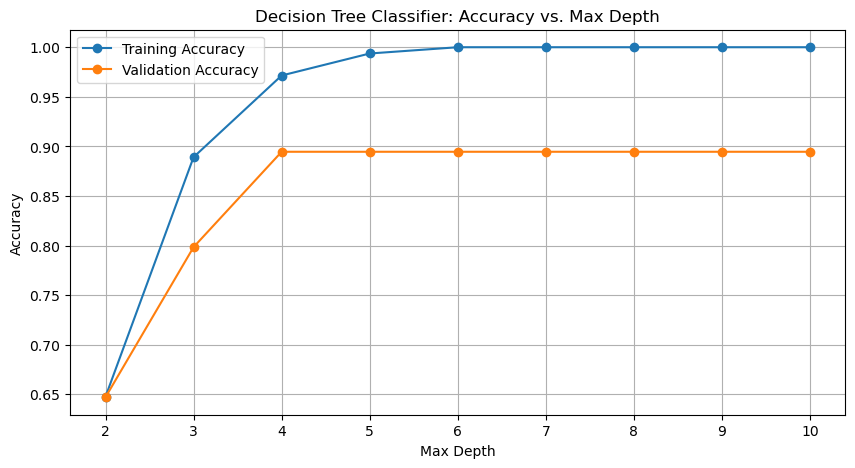

In [17]:
plot_decision_tree(results['Decision Tree'])

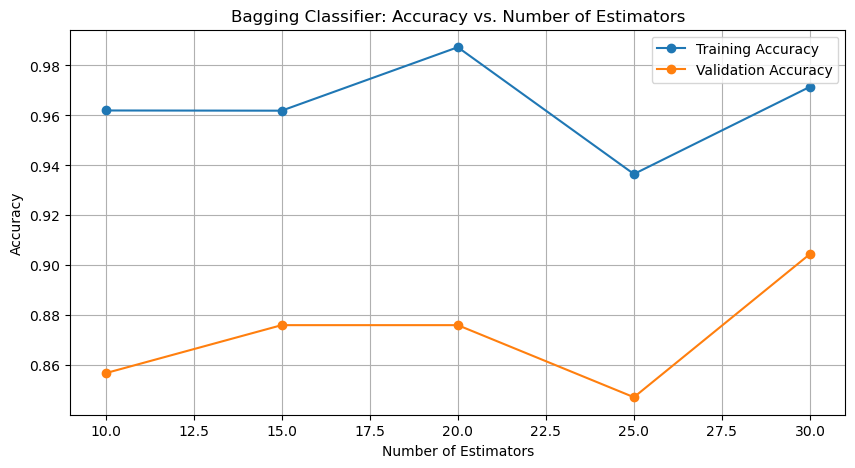

In [18]:
plot_bagging(results['Bagging'])

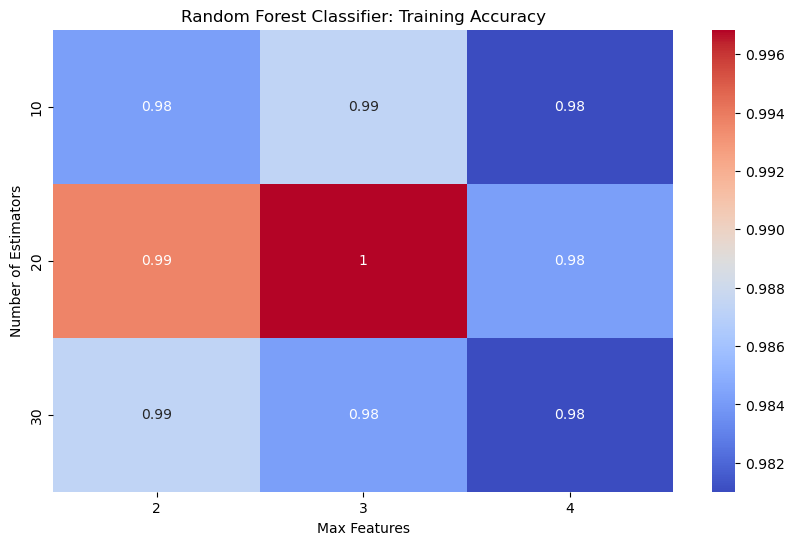

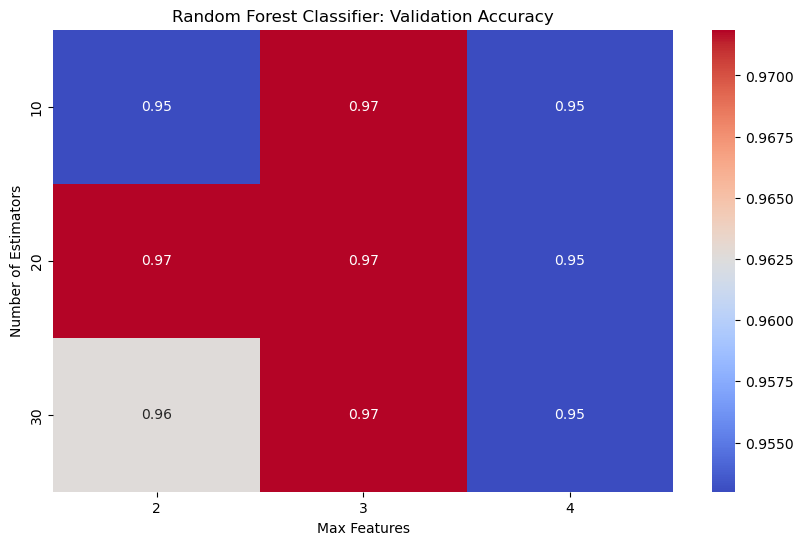

In [19]:
plot_random_forest(results['Random Forest'])

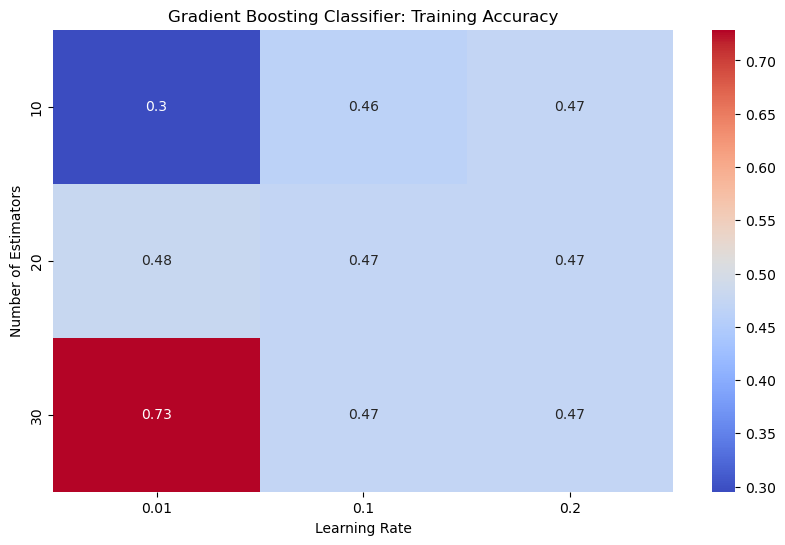

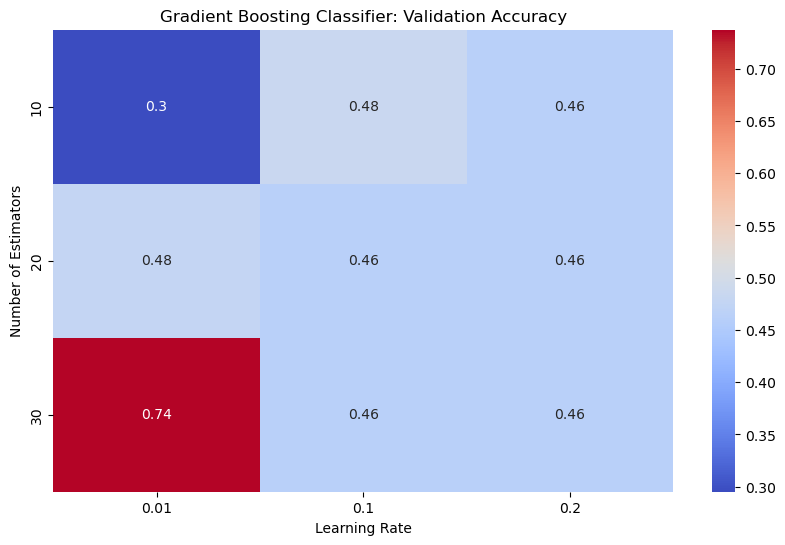

In [20]:
plot_gradient_boosting(results['Gradient Boosting'])

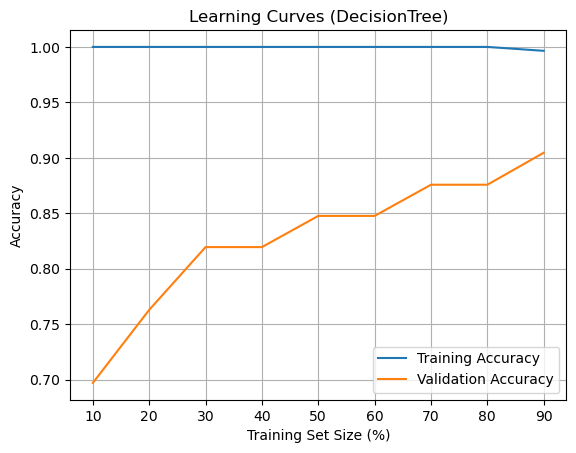

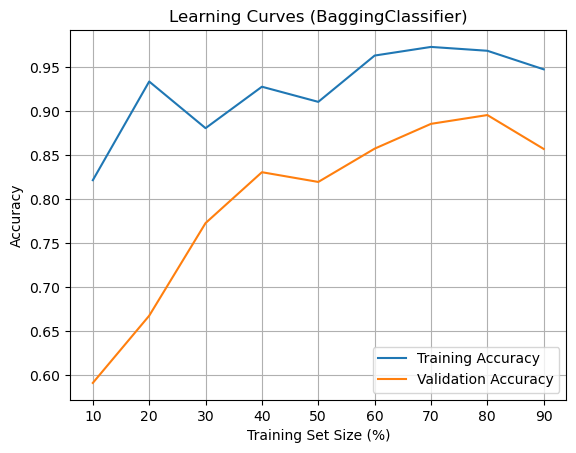

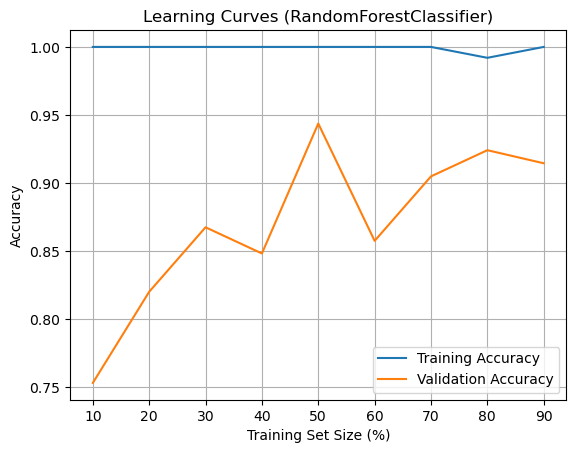

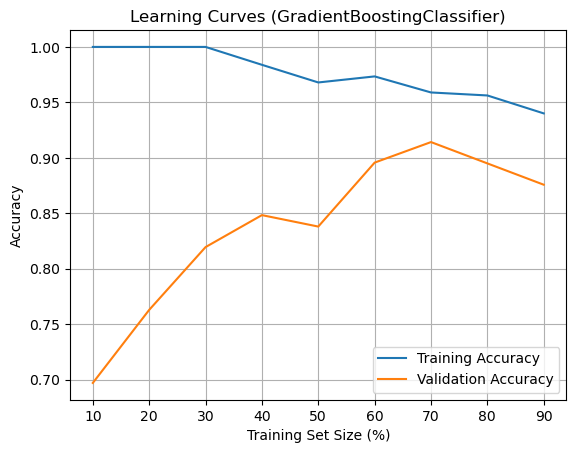

In [35]:
def plot_learning_curves(model_class, X, y, param_grid={}, train_sizes=np.linspace(0.1, 0.9, 9), k=4, **kwargs):
    train_mean_accuracies = []
    val_mean_accuracies = []

    for train_size in train_sizes:
        train_accuracies = []
        val_accuracies = []
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        
        for train_idx, val_idx in kf.split(X):
            X_train_fold, X_val_fold = X[train_idx], X[val_idx]
            y_train_fold, y_val_fold = y[train_idx], y[val_idx]

            
            if train_size < 1.0:
                X_train_sub, _, y_train_sub, _ = train_test_split(X_train_fold, y_train_fold, train_size=train_size, random_state=42)
            else:
                X_train_sub, y_train_sub = X_train_fold, y_train_fold

            model = model_class(**param_grid, **kwargs)
            model.fit(X_train_sub, y_train_sub)

            train_accuracies.append(np.mean(model.predict(X_train_sub) == y_train_sub))
            val_accuracies.append(np.mean(model.predict(X_val_fold) == y_val_fold))

        train_mean_accuracies.append(np.mean(train_accuracies))
        val_mean_accuracies.append(np.mean(val_accuracies))

    plt.plot(train_sizes * 100, train_mean_accuracies, label="Training Accuracy")
    plt.plot(train_sizes * 100, val_mean_accuracies, label="Validation Accuracy")
    plt.xlabel("Training Set Size (%)")
    plt.ylabel("Accuracy")
    plt.title(f"Learning Curves ({model_class.__name__})")
    plt.legend()
    plt.grid()
    plt.show()

model_classes = {
    "Decision Tree": DecisionTree,
    "Bagging Classifier": BaggingClassifier,
    "Random Forest": RandomForestClassifier,
    "Gradient Boosting": GradientBoostingClassifier
}

for model_name, model_class in model_classes.items():
    if model_name == "Bagging Classifier":
        plot_learning_curves(model_class, X_train, y_train, param_grid={"base_model": DecisionTree(max_depth=3)}, n_estimators=20)
    elif model_name == "Random Forest":
        plot_learning_curves(model_class, X_train, y_train, param_grid={"n_estimators": 20, "max_features": 2})
    elif model_name == "Gradient Boosting":
        plot_learning_curves(model_class, X_train, y_train, param_grid={"n_estimators": 20, "learning_rate": 0.1, "max_depth": 3})
    else:
        plot_learning_curves(model_class, X_train, y_train, param_grid={"max_depth": 5})


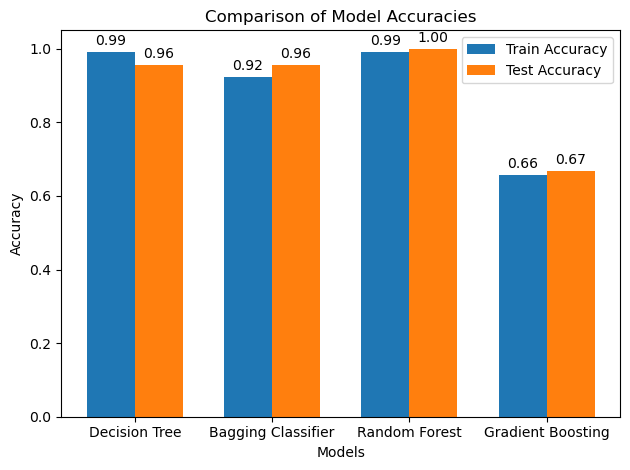

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def get_model_accuracy(model_class, X_train, y_train, X_test, y_test, **kwargs):
    model = model_class(**kwargs)
    model.fit(X_train, y_train)
    train_accuracy = np.mean(model.predict(X_train) == y_train)
    test_accuracy = np.mean(model.predict(X_test) == y_test)
    return train_accuracy, test_accuracy


model_classes = {
    "Decision Tree": (DecisionTree, {"max_depth": 5}),
    "Bagging Classifier": (BaggingClassifier, {"base_model": DecisionTree(max_depth=3), "n_estimators": 20}),
    "Random Forest": (RandomForestClassifier, {"n_estimators": 20, "max_features": 2}),
    "Gradient Boosting": (GradientBoostingClassifier, {"n_estimators": 20, "learning_rate": 0.1, "max_depth": 3})
}


train_accuracies = []
test_accuracies = []
model_names = []

for model_name, (model_class, params) in model_classes.items():
    train_acc, test_acc = get_model_accuracy(model_class, X_train, y_train, X_test, y_test, **params)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    model_names.append(model_name)


x = np.arange(len(model_names)) 
width = 0.35 

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, train_accuracies, width, label='Train Accuracy')
rects2 = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy')


ax.set_xlabel('Models')
ax.set_ylabel('Accuracy')
ax.set_title('Comparison of Model Accuracies')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()
